## Introduction
Customer churn poses a fundamental threat to business sustainability across industries, but nowhere is this more pronounced than in subscription-based models. The economics are stark: business success ultimately reduces to the ratio of Customer Lifetime Value (CLV) to Customer Acquisition Cost (CAC). When this ratio deteriorates due to churn, companies face an unsustainable growth trajectory.

Preventing churn delivers massive exponential benefits for business growth. The primary impact is immediately measurable. Retaining customers directly extends their lifetime value simply through duration. A customer who stays 24 months instead of 12 months doubles their contribution to revenue, dramatically improving the CLV/CAC ratio.

Beyond these quantifiable benefits lie significant secondary advantages. Retained customers often demonstrate increased willingness to pay for additional services over time, further amplifying their lifetime value. As customers become more comfortable with a service, they face greater switching costs and friction, making them inherently more stable. This creates a virtuous cycle where retention breeds retention.

The strategic implications extend to customer acquisition efficiency as well. Companies with lower churn rates can afford to be more selective in their acquisition strategies, focusing resources on higher-ROI channels rather than desperately replacing departing customers. The additional cash flow from improved retention can fund more sophisticated and efficient acquisition programs.

While these secondary benefits may require time to fully materialize, the primary benefits alone justify significant investment in churn prevention capabilities.

**This project develops a comprehensive churn prediction solution using XGBoost machine learning and an interactive Streamlit dashboard, enabling telecommunications companies to:**

- Identify at-risk customers before they churn
- Optimize the critical CLV/CAC ratio through proactive retention
- Transform customer data into actionable business intelligence
- Move from reactive customer service to strategic retention management

The solution addresses one of the most consequential metrics in subscription business models: keeping customers longer to unlock exponential growth benefits.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score
from sklearn.ensemble import RandomForestClassifier
import warnings
warnings.filterwarnings('ignore')

In [5]:
# Set style for better plots
plt.style.use('default')
sns.set_palette("Set2")
plt.rcParams['figure.figsize'] = (10, 6)

In [6]:
df = pd.read_csv('data/churn_raw.csv')

## Data Cleaning + Preprocessing

In [7]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [9]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


These three columns look great. Now how we'll go about handling the rest:
- Drop customerID (not needed for our analysis)
- Convert TotalCharges to numeric
- Encode all categorical variables

In [10]:
# Drop customerID (not useful for prediction)
df = df.drop('customerID', axis=1)

In [11]:
# Convert TotalCharges to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# 1. TotalCharges should roughly equal MonthlyCharges × tenure
df['expected_total'] = df['MonthlyCharges'] * df['tenure']
df['total_ratio'] = df['TotalCharges'] / df['expected_total']

# Flag records where actual is way off from expected
weird_totals = df[(df['total_ratio'] < 0.5) | (df['total_ratio'] > 2.0)]
print(f"Records with suspicious TotalCharges: {len(weird_totals)}")

# 2. Customers with 0 tenure shouldn't have TotalCharges
zero_tenure_with_charges = df[(df['tenure'] == 0) & (df['TotalCharges'] > 0)]
print(f"Zero tenure but has charges: {len(zero_tenure_with_charges)}")

# 3. MonthlyCharges should be positive
negative_monthly = df[df['MonthlyCharges'] <= 0]
print(f"Non-positive MonthlyCharges: {len(negative_monthly)}")

# 4. TotalCharges should be non-negative
negative_total = df[df['TotalCharges'] < 0]
print(f"Negative TotalCharges: {len(negative_total)}")

# 5. Drop new cols
df = df.drop(['expected_total', 'total_ratio'], axis=1)

Records with suspicious TotalCharges: 0
Zero tenure but has charges: 0
Non-positive MonthlyCharges: 0
Negative TotalCharges: 0


Looks good. Now for encoding.

In [12]:
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print("Categorical columns needing encoding:", categorical_cols)

Categorical columns needing encoding: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']


In [13]:
# Separate binary vs multi-category columns
binary_cols = []
multi_category_cols = []

for col in categorical_cols:
   unique_count = df[col].nunique()
   unique_values = df[col].unique()
   
   print(f"\n{col}: {unique_count} unique values - {unique_values}")
   
   if unique_count == 2:
       binary_cols.append(col)
   else:
       multi_category_cols.append(col)

print(f"\nENCODING PLAN")
print(f"Binary columns (convert to 0/1): {binary_cols}")
print(f"Multi-category columns (one-hot encode): {multi_category_cols}")


gender: 2 unique values - ['Female' 'Male']

Partner: 2 unique values - ['Yes' 'No']

Dependents: 2 unique values - ['No' 'Yes']

PhoneService: 2 unique values - ['No' 'Yes']

MultipleLines: 3 unique values - ['No phone service' 'No' 'Yes']

InternetService: 3 unique values - ['DSL' 'Fiber optic' 'No']

OnlineSecurity: 3 unique values - ['No' 'Yes' 'No internet service']

OnlineBackup: 3 unique values - ['Yes' 'No' 'No internet service']

DeviceProtection: 3 unique values - ['No' 'Yes' 'No internet service']

TechSupport: 3 unique values - ['No' 'Yes' 'No internet service']

StreamingTV: 3 unique values - ['No' 'Yes' 'No internet service']

StreamingMovies: 3 unique values - ['No' 'Yes' 'No internet service']

Contract: 3 unique values - ['Month-to-month' 'One year' 'Two year']

PaperlessBilling: 2 unique values - ['Yes' 'No']

PaymentMethod: 4 unique values - ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']

Churn: 2 unique values - ['No' 'Ye

In [14]:
# Encode binary columns to 0/1
for col in binary_cols:
    unique_vals = df[col].unique()
    print(f"Encoding {col}: {unique_vals}")
    
    if 'Yes' in unique_vals:
        df[col] = df[col].map({'Yes': 1, 'No': 0})
    elif 'Male' in unique_vals:
        df[col] = df[col].map({'Male': 1, 'Female': 0})
    
    print(f"After encoding: {df[col].unique()}")

# One-hot encode multi-category columns
print(f"\nBefore one-hot encoding: {df.shape}")
df = pd.get_dummies(df, columns=multi_category_cols, drop_first=True)
print(f"After one-hot encoding: {df.shape}")

# Final check - should be all numeric now
print(f"\nFinal data types:")
print(df.dtypes.value_counts())

remaining_objects = df.select_dtypes(include=['object']).columns.tolist()
if len(remaining_objects) == 0:
    print("SUCCESS!")
else:
    print(f"Still have text columns: {remaining_objects}")

Encoding gender: ['Female' 'Male']
After encoding: [0 1]
Encoding Partner: ['Yes' 'No']
After encoding: [1 0]
Encoding Dependents: ['No' 'Yes']
After encoding: [0 1]
Encoding PhoneService: ['No' 'Yes']
After encoding: [0 1]
Encoding PaperlessBilling: ['Yes' 'No']
After encoding: [1 0]
Encoding Churn: ['No' 'Yes']
After encoding: [0 1]

Before one-hot encoding: (7043, 20)
After one-hot encoding: (7043, 31)

Final data types:
bool       21
int64       8
float64     2
Name: count, dtype: int64
SUCCESS!


## Exploratory Data Analysis (EDA)
The purpose of this exploratory data analysis is to understand the key factors driving customer churn in our telecommunications dataset. Through systematic examination of feature relationships and churn patterns, we aim to identify the most predictive variables that will inform our machine learning model development. Our analysis focuses on examining churn rates across different customer segments, including contract types, internet service offerings, payment methods, and customer tenure. By visualizing these relationships and quantifying their statistical significance through correlation analysis, we can prioritize the most impactful features for our predictive model. This data-driven approach ensures that our subsequent XGBoost model is built on solid analytical foundations, ultimately leading to more accurate churn predictions and actionable business insights for customer retention strategies.


Overall churn rate: 26.5%
Churn distribution: Churn
0    5174
1    1869
Name: count, dtype: int64


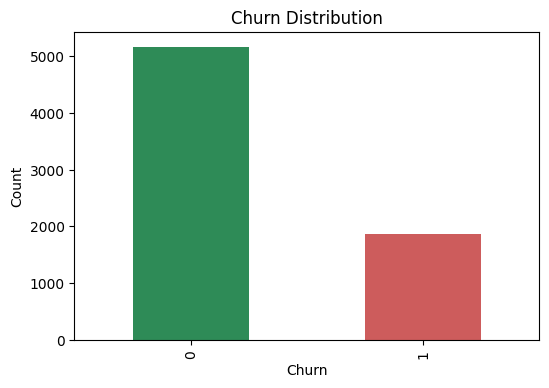

In [15]:
churn_rate = df['Churn'].mean()
churn_counts = df['Churn'].value_counts()
print(f"Overall churn rate: {churn_rate:.1%}")
print(f"Churn distribution: {churn_counts}")

plt.figure(figsize=(6, 4))
df['Churn'].value_counts().plot(kind='bar',color=['seagreen', 'indianred'])
plt.title('Churn Distribution')
plt.ylabel('Count')
plt.show()

Let's look at how our potential feature columns correlate with our churn target

In [16]:
# Get all features except target
features = [col for col in df.columns if col != 'Churn']

# Calculate correlations with churn (only for numeric columns)
correlations = []
for feature in features:
    # Check if column is numeric
    if df[feature].dtype in ['int64', 'float64', 'bool']:
        try:
            corr = df[feature].corr(df['Churn'])
            if not pd.isna(corr):  # Skip if correlation is NaN
                correlations.append({
                    'feature': feature,
                    'correlation': abs(corr),  # Absolute value to see strength
                    'raw_correlation': corr
                })
        except:
            print(f"Skipping {feature} - couldn't calculate correlation")
    else:
        print(f"Skipping {feature} - not numeric (type: {df[feature].dtype})")

# Sort by correlation strength
corr_df = pd.DataFrame(correlations).sort_values('correlation', ascending=False)

print("\nTOP 15 FEATURES BY CORRELATION WITH CHURN:")
for i, row in corr_df.head(15).iterrows():
    direction = "↑" if row['raw_correlation'] > 0 else "↓"
    print(f"{row['feature']:<50} {direction} {row['correlation']:.3f}")


TOP 15 FEATURES BY CORRELATION WITH CHURN:
tenure                                             ↓ 0.352
InternetService_Fiber optic                        ↑ 0.308
Contract_Two year                                  ↓ 0.302
PaymentMethod_Electronic check                     ↑ 0.302
InternetService_No                                 ↓ 0.228
OnlineSecurity_No internet service                 ↓ 0.228
DeviceProtection_No internet service               ↓ 0.228
TechSupport_No internet service                    ↓ 0.228
StreamingMovies_No internet service                ↓ 0.228
StreamingTV_No internet service                    ↓ 0.228
OnlineBackup_No internet service                   ↓ 0.228
TotalCharges                                       ↓ 0.199
MonthlyCharges                                     ↑ 0.193
PaperlessBilling                                   ↑ 0.192
Contract_One year                                  ↓ 0.178


Based on the correlations we'll hone in on the following four columns from our original data
- Tenure
- Contract
- Internet Service
- Payment Method

In [17]:
# Churn rate by tenure groups
df['tenure_group'] = pd.cut(df['tenure'], 
                           bins=[0, 6, 12, 24, 36, 72], 
                           labels=['0-6mo', '6-12mo', '1-2yr', '2-3yr', '3+yr'])

churn_by_tenure = df.groupby('tenure_group')['Churn'].agg(['count', 'sum', 'mean'])

# Rename columns to be clear
churn_by_tenure.columns = ['Total_Customers', 'Churned_Customers', 'Churn_Rate']

print("Churn analysis by customer tenure:")
print(churn_by_tenure.round(3))

Churn analysis by customer tenure:
              Total_Customers  Churned_Customers  Churn_Rate
tenure_group                                                
0-6mo                    1470                784       0.533
6-12mo                    705                253       0.359
1-2yr                    1024                294       0.287
2-3yr                     832                180       0.216
3+yr                     3001                358       0.119


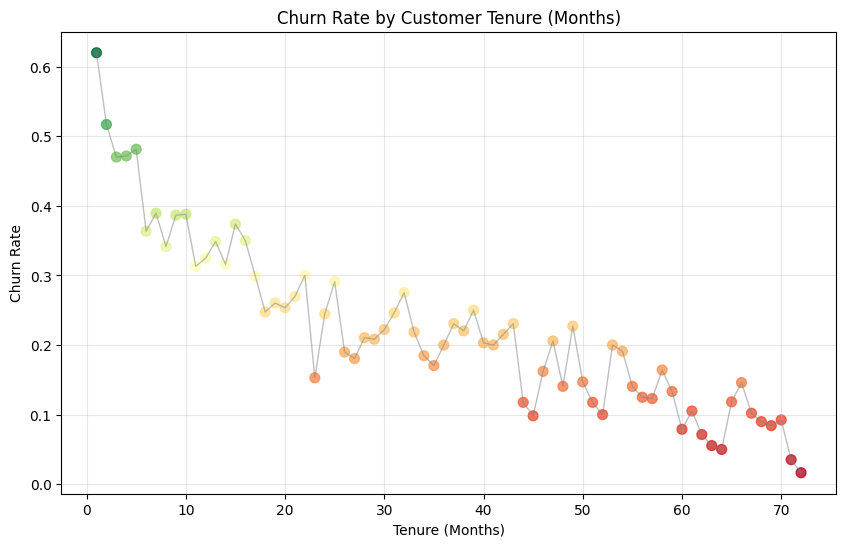

Tenure = 0 analysis:
Customers with 0 tenure: 11.0
Churn rate for 0 tenure: 0.000


In [18]:
# Plot churn rate by tenure with gradient (excluding tenure = 0)
plt.figure(figsize=(10, 6))

# Filter out tenure = 0 to avoid misleading spike
df_filtered = df[df['tenure'] > 0]
churn_by_tenure_month = df_filtered.groupby('tenure')['Churn'].mean()

# Create gradient from red (high churn) to green (low churn)
colors = plt.cm.RdYlGn_r(1 - churn_by_tenure_month.values / churn_by_tenure_month.max())

# Use scatter plot with gradient colors
plt.scatter(churn_by_tenure_month.index, churn_by_tenure_month.values, 
          c=colors, s=50, alpha=0.8)

# Add a connecting line for continuity
plt.plot(churn_by_tenure_month.index, churn_by_tenure_month.values, 
        color='gray', alpha=0.5, linewidth=1)

plt.title('Churn Rate by Customer Tenure (Months)')
plt.xlabel('Tenure (Months)')
plt.ylabel('Churn Rate')
plt.grid(True, alpha=0.3)
plt.show()

# Also check what tenure = 0 looks like
print("Tenure = 0 analysis:")
tenure_zero = df[df['tenure'] == 0]['Churn'].agg(['count', 'mean'])
print(f"Customers with 0 tenure: {tenure_zero['count']}")
print(f"Churn rate for 0 tenure: {tenure_zero['mean']:.3f}")

In [19]:
# Select contract type columns
contract_cols = [col for col in df.columns if 'Contract' in col]
contract_cols

['Contract_One year', 'Contract_Two year']

Churn analysis by contract type:
                Total_Customers  Churn_Rate
Contract_Type                              
Month-to-month             3875       0.427
One year                   1473       0.113
Two year                   1695       0.028


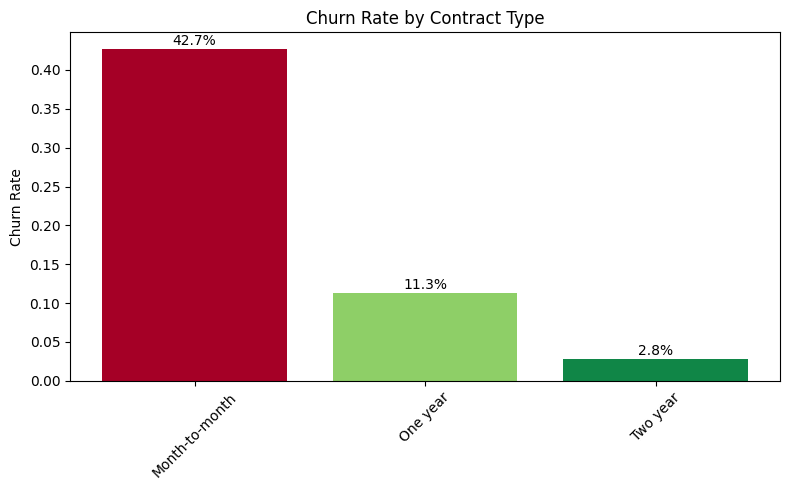

In [20]:
# Create a summary showing all contract types
# Remember: if both Contract_One year and Contract_Two year are 0, then it's Month-to-month
df['Contract_Type'] = 'Month-to-month'  # Default
df.loc[df['Contract_One year'] == 1, 'Contract_Type'] = 'One year'
df.loc[df['Contract_Two year'] == 1, 'Contract_Type'] = 'Two year'

# Analyze churn by contract type
contract_analysis = df.groupby('Contract_Type')['Churn'].agg(['count', 'mean']).round(3)
contract_analysis.columns = ['Total_Customers', 'Churn_Rate']
print("Churn analysis by contract type:")
print(contract_analysis)

# Visualization with gradient
plt.figure(figsize=(8, 5))
contract_churn = df.groupby('Contract_Type')['Churn'].mean().sort_values(ascending=False)

# Create gradient: green (low churn) to red (high churn)
colors = plt.cm.RdYlGn_r(contract_churn.values / contract_churn.max())

bars = plt.bar(contract_churn.index, contract_churn.values, color=colors)
plt.title('Churn Rate by Contract Type')
plt.ylabel('Churn Rate')
plt.xticks(rotation=45)

# Add value labels on bars
for bar, value in zip(bars, contract_churn.values):
   plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{value:.1%}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

In [21]:
# Select internet service cols
internet_cols = [col for col in df.columns if 'Internet' in col]
internet_cols


['InternetService_Fiber optic', 'InternetService_No']

Churn analysis by internet type:
               Total_Customers  Churn_Rate
Internet_Type                             
DSL                       2421       0.190
Fiber optic               3096       0.419
No Internet               1526       0.074


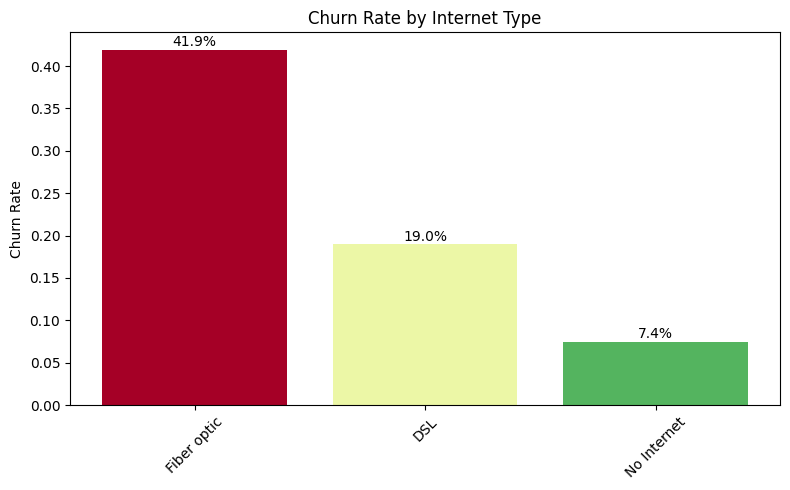

In [22]:
# Create a summary showing all internet types
df['Internet_Type'] = 'DSL'  # DSL is the default/baseline
df.loc[df['InternetService_Fiber optic'] == 1, 'Internet_Type'] = 'Fiber optic'
df.loc[df['InternetService_No'] == 1, 'Internet_Type'] = 'No Internet'

# Analyze churn by internet type
internet_analysis = df.groupby('Internet_Type')['Churn'].agg(['count', 'mean']).round(3)
internet_analysis.columns = ['Total_Customers', 'Churn_Rate']
print("Churn analysis by internet type:")
print(internet_analysis)

# Visualization with gradient
plt.figure(figsize=(8, 5))
internet_churn = df.groupby('Internet_Type')['Churn'].mean().sort_values(ascending=False)

# Create gradient: green (low churn) to red (high churn)
colors = plt.cm.RdYlGn_r(internet_churn.values / internet_churn.max())

bars = plt.bar(internet_churn.index, internet_churn.values, color=colors)
plt.title('Churn Rate by Internet Type')
plt.ylabel('Churn Rate')
plt.xticks(rotation=45)

# Add value labels on bars
for bar, value in zip(bars, internet_churn.values):
   plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{value:.1%}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

In [23]:
# Select payment method columns
payment_cols = [col for col in df.columns if 'Payment' in col]
payment_cols

['PaymentMethod_Credit card (automatic)',
 'PaymentMethod_Electronic check',
 'PaymentMethod_Mailed check']

Churn analysis by payment method:
                           Total_Customers  Churn_Rate
Payment_Method                                        
Bank transfer (automatic)             1544       0.167
Credit card (automatic)               1522       0.152
Electronic check                      2365       0.453
Mailed check                          1612       0.191


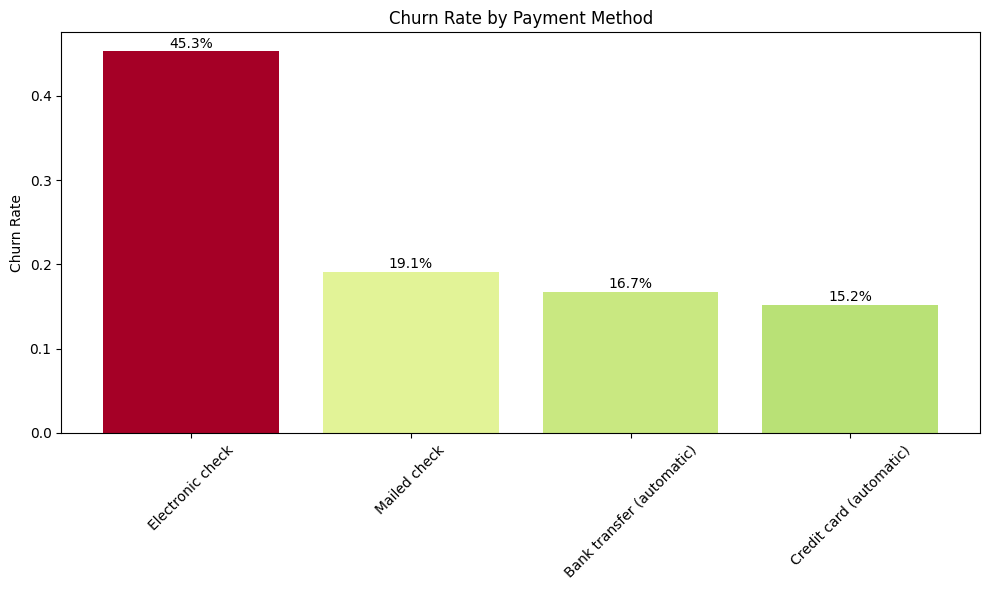

In [24]:
# Create readable payment method column
df['Payment_Method'] = 'Bank transfer (automatic)'  # Default (the dropped one)
df.loc[df['PaymentMethod_Electronic check'] == 1, 'Payment_Method'] = 'Electronic check'
df.loc[df['PaymentMethod_Mailed check'] == 1, 'Payment_Method'] = 'Mailed check'
df.loc[df['PaymentMethod_Credit card (automatic)'] == 1, 'Payment_Method'] = 'Credit card (automatic)'

# Analyze churn by payment method
payment_analysis = df.groupby('Payment_Method')['Churn'].agg(['count', 'mean']).round(3)
payment_analysis.columns = ['Total_Customers', 'Churn_Rate']
print("Churn analysis by payment method:")
print(payment_analysis)

# Visualization with gradient based on churn rate
plt.figure(figsize=(10, 6))
payment_churn = df.groupby('Payment_Method')['Churn'].mean().sort_values(ascending=False)

# Create gradient: green (low churn) to red (high churn)
colors = plt.cm.RdYlGn_r(payment_churn.values / payment_churn.max())

# Use bar plot with gradient colors
bars = plt.bar(payment_churn.index, payment_churn.values, color=colors)
plt.title('Churn Rate by Payment Method')
plt.ylabel('Churn Rate')
plt.xticks(rotation=45)

# Add value labels on bars
for bar, value in zip(bars, payment_churn.values):
   plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{value:.1%}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

Our analysis identified the four key churn drivers: month-to-month contracts have much higher churn than annual contracts, fiber optic customers unexpectedly churn more than DSL users, electronic check payers are high-risk compared to automatic payments, and new customers (low tenure) churn way more than long-term customers. These four features show the strongest correlations with churn (0.30+ correlation) and give us the main predictors for our XGBoost model.

## Machine Learning Model Development

In [25]:

# Use the top features from our EDA analysis (including all one-hot encoded versions)
top_features = [
    'tenure', 
    'InternetService_Fiber optic', 'InternetService_No',        # All internet types
    'Contract_One year', 'Contract_Two year',                   # All contract types  
    'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check', 'PaymentMethod_Credit card (automatic)'  # All payment methods
]
X = df[top_features]
y = df['Churn']

print(f"\nFeatures for modeling: {X.shape[1]} columns")
print(f"Selected features: {list(X.columns)}")

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

print(f"Training set: {X_train.shape[0]} samples ({y_train.mean():.1%} churn rate)")
print(f"Test set: {X_test.shape[0]} samples ({y_test.mean():.1%} churn rate)")


Features for modeling: 8 columns
Selected features: ['tenure', 'InternetService_Fiber optic', 'InternetService_No', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check', 'PaymentMethod_Credit card (automatic)']
Training set: 5634 samples (26.5% churn rate)
Test set: 1409 samples (26.5% churn rate)


In [26]:
# Create and train the model
rf_model = RandomForestClassifier(
    n_estimators=100,    # 100 trees
    random_state=42,     # Reproducible results
    max_depth=10,        # Prevent overfitting
    min_samples_split=5  # Need at least 5 samples to split a node
)

print("\nTraining Random Forest...")
rf_model.fit(X_train, y_train)
print("✅ Model trained!")

# Make predictions
y_pred = rf_model.predict(X_test)
y_pred_proba = rf_model.predict_proba(X_test)[:, 1]  # Probability of churn

# Evaluate performance
accuracy = accuracy_score(y_test, y_pred)
auc_score = roc_auc_score(y_test, y_pred_proba)

print(f"\n=== MODEL PERFORMANCE ===")
print(f"Accuracy: {accuracy:.3f} ({accuracy:.1%})")
print(f"AUC Score: {auc_score:.3f}")

# Quick interpretation
if accuracy >= 0.85 and auc_score >= 0.85:
    print("🎉 EXCELLENT performance! Ready for deployment.")
elif accuracy >= 0.75 and auc_score >= 0.75:
    print("👍 GOOD performance! Could try XGBoost for improvement.")
else:
    print("⚠️  Needs improvement. Check data preprocessing.")

print(f"\n=== DETAILED RESULTS ===")
print("Classification Report:")
print(classification_report(y_test, y_pred))


Training Random Forest...
✅ Model trained!

=== MODEL PERFORMANCE ===
Accuracy: 0.778 (77.8%)
AUC Score: 0.823
👍 GOOD performance! Could try XGBoost for improvement.

=== DETAILED RESULTS ===
Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.88      0.85      1035
           1       0.60      0.49      0.54       374

    accuracy                           0.78      1409
   macro avg       0.71      0.69      0.70      1409
weighted avg       0.77      0.78      0.77      1409

